# PolyMomentum strategy portfolio and fresh-block power decision

**Decision:** which strategy mechanism has enough causal and statistical support to remain in the A+ research path?  
**As of:** 2026-07-18  
**Policy:** historical lifecycle variants are diagnostic only; the binary-complement rule is forward-only and remains sealed below its fixed block floor.

In [1]:
from pathlib import Path
import hashlib
import json
import math

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'rust_engine').is_dir():
    ROOT = ROOT.parents[1]
assert (ROOT / 'rust_engine').is_dir(), ROOT
plt.style.use('seaborn-v0_8-whitegrid')
ROOT

PosixPath('/Users/ttoomm/Documents/PolyMomentum')

In [2]:
sources = {
    'strict42': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_forward_window_admissibility_pipeline.json',
    'lifecycle_v1': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_complete_set_lock_v1_historical_tail_diagnostic.json',
    'lifecycle_v2': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_trailing_complete_set_lock_v2_historical_tail_diagnostic.json',
    'power': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_binary_complement_blinded_power_amendment.json',
    'preregistration': ROOT / 'deploy/promotions/evidence/strategy_registry/20260715_binary_complement_coherence_preregistration.json',
    'collection': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_binary_complement_block1_collection_status.json',
    'fixed_support': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_binary_complement_fixed_support_collection_plan.json',
    'economic_diagnostics': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_binary_complement_prescore_economic_diagnostics_amendment.json',
    'unit_economics_amendment': ROOT / 'deploy/promotions/evidence/strategy_registry/20260718_binary_complement_prescore_unit_economics_amendment.json',
}
data = {name: json.loads(path.read_text()) for name, path in sources.items()}
source_table = pd.DataFrame([
    {
        'source': name,
        'path': str(path.relative_to(ROOT)),
        'sha256': hashlib.sha256(path.read_bytes()).hexdigest(),
        'status': data[name].get('status', 'context'),
    }
    for name, path in sources.items()
])
assert data['lifecycle_v1']['status'] == 'REJECTED_BY_HISTORICAL_RESEARCH_DIAGNOSTIC'
assert data['lifecycle_v2']['status'] == 'REJECTED_BY_HISTORICAL_RESEARCH_DIAGNOSTIC'
assert data['power']['decision']['forward_metrics_seen_before_decision'] is False
assert data['preregistration']['forward_screen']['block_1']['minimum_terminal_settlement_aligned_conditions'] == 750
assert data['preregistration']['instrumentation']['scorer']['schema_version'] == 4
assert data['economic_diagnostics']['decision']['forward_strategy_metrics_seen'] is False
assert data['economic_diagnostics']['diagnostics']['gating_use'] == 'descriptive_only_non_gating'
assert data['unit_economics_amendment']['decision']['forward_strategy_metrics_seen'] is False
assert data['unit_economics_amendment']['decision']['economic_gate_set_changed'] is True
assert data['unit_economics_amendment']['new_fail_closed_gates'][0]['equivalent_existing_a_plus_threshold'] == 'profit_factor >= 1.20'
assert data['unit_economics_amendment']['new_fail_closed_gates'][1]['equivalent_existing_a_plus_threshold'] == 'payoff_ratio >= 0.20'
assert data['power']['decision']['source_and_freshness_integrity_strengthened'] is True
assert data['collection']['fixed_support_extension']['strategy_score_emitted'] is False
assert data['fixed_support']['decision']['strategy_metrics_seen'] is False
assert data['fixed_support']['support_integrity']['unsealed_or_rejected_segments_count'] is False
assert data['fixed_support']['verified_cleanup']['local_byte_identical_archives_preserved'] is True
source_table

,source,path,sha256,status
0,strict42,deploy/promotions/evidence/strategy_registry/2...,29494dce95c71b8300f975d420228f67c4dbc0486f024a...,REAL_CANARY_VALIDATED_NOT_DEPLOYED
1,lifecycle_v1,deploy/promotions/evidence/strategy_registry/2...,7096121aafc7354bb4d01f0eb42da328c3850c7f1176c8...,REJECTED_BY_HISTORICAL_RESEARCH_DIAGNOSTIC
2,lifecycle_v2,deploy/promotions/evidence/strategy_registry/2...,9908a5f6a009603db911ccc3ab67412657e0121dfc21ce...,REJECTED_BY_HISTORICAL_RESEARCH_DIAGNOSTIC
3,power,deploy/promotions/evidence/strategy_registry/2...,93158926e974fe1d763e0e336b9c715ab068b360204db3...,BLINDED_POWER_AMENDMENT_REGISTERED_BEFORE_FORW...
4,preregistration,deploy/promotions/evidence/strategy_registry/2...,0926fd7c232abf0b663d12941a3bd0fc7ae73ef9d66d85...,PRE_REGISTERED_FORWARD_ONLY_NOT_SCORED_POWER_A...
5,collection,deploy/promotions/evidence/strategy_registry/2...,8f40d4ce69ce90106f0c3ec3d377acf05674e89a3d35cd...,SEGMENT_003_SEALED_STABILITY_CANARY_ACTIVE_FLO...
6,fixed_support,deploy/promotions/evidence/strategy_registry/2...,aa2c341409a7334e37814e2baebaa23ac3c210c85744e0...,DEPLOYED_WAITING_FOR_STABILITY_CANARY
7,economic_diagnostics,deploy/promotions/evidence/strategy_registry/2...,f638d0f4db36915665dfcf1bed9774484a91d45b224d7f...,PRE_SCORE_DESCRIPTIVE_DIAGNOSTICS_REGISTERED_S...
8,unit_economics_amendment,deploy/promotions/evidence/strategy_registry/2...,170d96c7ae4e9e5b3aae1e367ce6833af1429efa594f56...,PRE_SCORE_UNIT_ECONOMICS_GATES_REGISTERED


## Historical mechanism triage

The lifecycle variants use the same 14-fold tail and can be compared directly. The strict-42 baseline is broader context, not a like-for-like lifecycle comparison. A+ reference gates shown here are profit factor ≥ 1.20, payoff ratio ≥ 0.20, Wilson lower bound ≥ 0.70, positive PnL in both chronological halves, and loss burst ≤ 2.

In [3]:
v1 = data['lifecycle_v1']['aggregate']['candidate']
v2 = data['lifecycle_v2']['aggregate']['candidate']
tail_baseline = data['lifecycle_v2']['aggregate']['baseline']
strict42 = data['strict42']['baseline']

portfolio = pd.DataFrame([
    {'mechanism': 'strict42 baseline (context)', 'window': '42 folds', 'trades': strict42['trades'], 'pnl_usd': strict42['fee_inclusive_pnl_usd'], 'profit_factor': strict42['profit_factor'], 'payoff_ratio': strict42['payoff_ratio'], 'wilson_lower': strict42['wilson_95_lower'], 'first_half_pnl': strict42['first_21_fold_pnl_usd'], 'second_half_pnl': strict42['last_21_fold_pnl_usd'], 'loss_burst': strict42['maximum_losses_in_five_reports'], 'verdict': 'A- / research-only'},
    {'mechanism': 'tail baseline', 'window': 'folds 29–42', 'trades': tail_baseline['trades'], 'pnl_usd': tail_baseline['total_pnl_usd'], 'profit_factor': tail_baseline['profit_factor'], 'payoff_ratio': tail_baseline['payoff_ratio'], 'wilson_lower': tail_baseline['wilson_95_lower'], 'first_half_pnl': tail_baseline['first_7_folds_pnl_usd'], 'second_half_pnl': tail_baseline['last_7_folds_pnl_usd'], 'loss_burst': tail_baseline['max_losses_in_rolling_5_folds'], 'verdict': 'diagnostic baseline'},
    {'mechanism': 'immediate complete-set v1', 'window': 'folds 29–42', 'trades': v1['trades'], 'pnl_usd': v1['total_pnl_usd'], 'profit_factor': v1['profit_factor'], 'payoff_ratio': v1['payoff_ratio'], 'wilson_lower': v1['wilson_95_lower'], 'first_half_pnl': v1['first_7_folds_pnl_usd'], 'second_half_pnl': v1['last_7_folds_pnl_usd'], 'loss_burst': v1['max_losses_in_rolling_5_folds'], 'verdict': 'rejected; no retuning'},
    {'mechanism': 'trailing complete-set v2', 'window': 'folds 29–42', 'trades': v2['trades'], 'pnl_usd': v2['total_pnl_usd'], 'profit_factor': v2['profit_factor'], 'payoff_ratio': v2['payoff_ratio'], 'wilson_lower': v2['wilson_95_lower'], 'first_half_pnl': v2['first_7_folds_pnl_usd'], 'second_half_pnl': v2['last_7_folds_pnl_usd'], 'loss_burst': v2['max_losses_in_rolling_5_folds'], 'verdict': 'rejected; no retuning'},
])
portfolio['positive_both_halves'] = (portfolio.first_half_pnl > 0) & (portfolio.second_half_pnl > 0)
portfolio['passes_displayed_a_plus_gates'] = (
    (portfolio.pnl_usd > 0)
    & (portfolio.profit_factor >= 1.20)
    & (portfolio.payoff_ratio >= 0.20)
    & (portfolio.wilson_lower >= 0.70)
    & portfolio.positive_both_halves
    & (portfolio.loss_burst <= 2)
)
portfolio

,mechanism,window,trades,pnl_usd,profit_factor,payoff_ratio,wilson_lower,first_half_pnl,second_half_pnl,loss_burst,verdict,positive_both_halves,passes_displayed_a_plus_gates
0,strict42 baseline (context),42 folds,102,13.54086,1.114236,0.324398,0.684308,17.87934,-4.33848,4,A- / research-only,False,False
1,tail baseline,folds 29–42,43,-12.58816,0.754868,0.228748,0.622555,-6.69209,-5.89607,4,diagnostic baseline,False,False
2,immediate complete-set v1,folds 29–42,66,-8.15098,0.679497,0.055696,0.834608,-1.83443,-6.31655,3,rejected; no retuning,False,False
3,trailing complete-set v2,folds 29–42,56,-2.28929,0.944057,0.157343,0.742641,-5.31740,3.02811,4,rejected; no retuning,False,False


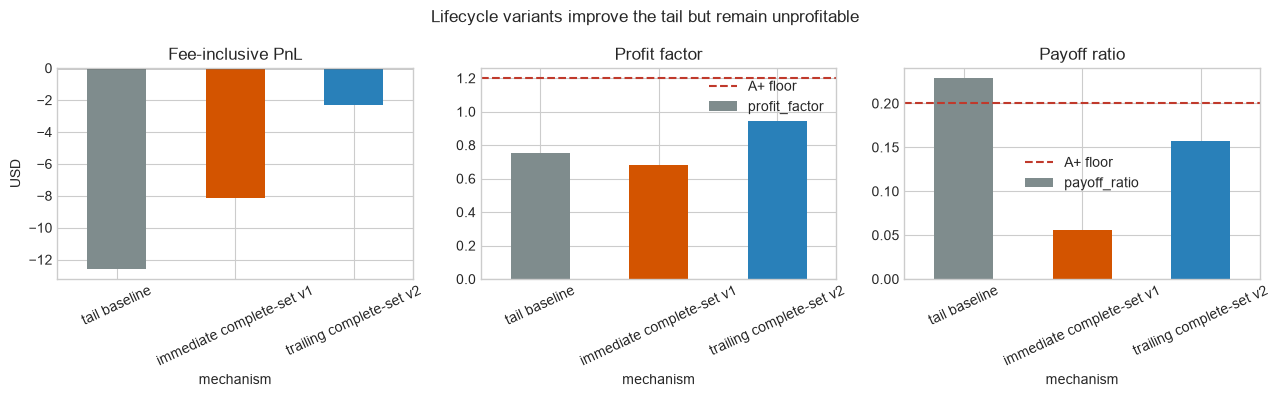

In [4]:
tail_plot = portfolio[portfolio.window == 'folds 29–42'].set_index('mechanism')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
tail_plot.pnl_usd.plot.bar(ax=axes[0], color=['#7f8c8d', '#d35400', '#2980b9'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Fee-inclusive PnL')
axes[0].set_ylabel('USD')
tail_plot.profit_factor.plot.bar(ax=axes[1], color=['#7f8c8d', '#d35400', '#2980b9'])
axes[1].axhline(1.20, color='#c0392b', linestyle='--', label='A+ floor')
axes[1].set_title('Profit factor')
axes[1].legend()
tail_plot.payoff_ratio.plot.bar(ax=axes[2], color=['#7f8c8d', '#d35400', '#2980b9'])
axes[2].axhline(0.20, color='#c0392b', linestyle='--', label='A+ floor')
axes[2].set_title('Payoff ratio')
axes[2].legend()
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
fig.suptitle('Lifecycle variants improve the tail but remain unprofitable')
fig.tight_layout()
plt.show()

## Blinded fresh-block power analysis

The binary-complement trading rule is unchanged. This section uses only historical nuisance rates—how often the baseline fires and loses—to choose a fixed disclosure size before any fresh outcome metric exists.

In [5]:
z = 1.959963984540054
candidate_rate = 102 / 631
loss_rate = 23 / 631
baseline_win_share = 79 / 102
winner_retention = 0.90
loss_retention = 0.70
selected_rate_given_candidate = baseline_win_share * winner_retention + (1 - baseline_win_share) * loss_retention
selected_win_rate = baseline_win_share * winner_retention / selected_rate_given_candidate

def wilson_lower(wins, trades):
    p = wins / trades
    return (p + z*z/(2*trades) - z*math.sqrt((p*(1-p) + z*z/(4*trades))/trades)) / (1 + z*z/trades)

def binomial_tail(n, p, minimum):
    return sum(math.comb(n, k) * p**k * (1-p)**(n-k) for k in range(minimum, n + 1))

power_rows = []
for conditions in [100, 120, 300, 500, 600, 700, 725, 750]:
    expected_candidates = conditions * candidate_rate
    expected_losses = conditions * loss_rate
    expected_selected = expected_candidates * selected_rate_given_candidate
    expected_selected_wins = conditions * (79 / 631) * winner_retention
    power_rows.append({
        'terminal_conditions': conditions,
        'expected_baseline_candidates': expected_candidates,
        'expected_baseline_losses': expected_losses,
        'expected_selected_candidates': expected_selected,
        'expected_selected_win_rate': selected_win_rate,
        'expected_wilson_lower': wilson_lower(round(expected_selected_wins), round(expected_selected)),
        'P(baseline_candidates>=100)': binomial_tail(conditions, candidate_rate, 100),
        'P(baseline_losses>=15)': binomial_tail(conditions, loss_rate, 15),
    })
power_table = pd.DataFrame(power_rows)
power_table.round(4)

,terminal_conditions,expected_baseline_candidates,expected_baseline_losses,expected_selected_candidates,expected_selected_win_rate,expected_wilson_lower,P(baseline_candidates>=100),P(baseline_losses>=15)
0,100,16.1648,3.6450,13.8193,0.8154,0.5241,0.0000,0.0000
1,120,19.3978,4.3740,16.5832,0.8154,0.5897,0.0000,0.0000
2,300,48.4945,10.9350,41.4580,0.8154,0.6874,0.0000,0.1372
3,500,80.8241,18.2250,69.0967,0.8154,0.7039,0.0133,0.8112
4,600,96.9889,21.8700,82.9160,0.8154,0.7230,0.3859,0.9526
5,700,113.1537,25.5151,96.7353,0.8154,0.7256,0.9213,0.9913
6,725,117.1949,26.4263,100.1902,0.8154,0.7333,0.9650,0.9945
7,750,121.2361,27.3376,103.6450,0.8154,0.7322,0.9861,0.9966


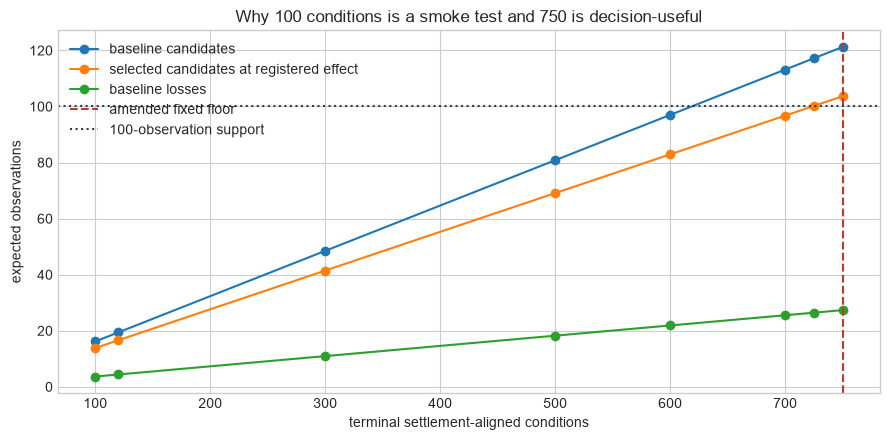

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(power_table.terminal_conditions, power_table.expected_baseline_candidates, marker='o', label='baseline candidates')
ax.plot(power_table.terminal_conditions, power_table.expected_selected_candidates, marker='o', label='selected candidates at registered effect')
ax.plot(power_table.terminal_conditions, power_table.expected_baseline_losses, marker='o', label='baseline losses')
ax.axvline(750, color='#c0392b', linestyle='--', label='amended fixed floor')
ax.axhline(100, color='#2c3e50', linestyle=':', label='100-observation support')
ax.set_xlabel('terminal settlement-aligned conditions')
ax.set_ylabel('expected observations')
ax.set_title('Why 100 conditions is a smoke test and 750 is decision-useful')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [7]:
collection = data['collection']
fixed_support = data['fixed_support']
unit_economics_amendment = data['unit_economics_amendment']
capacity = fixed_support['capacity_model']
economic_history = unit_economics_amendment['historical_sanity_envelope']
proportional_pf = economic_history['baseline_profit_factor'] * economic_history['registered_minimum_winner_retention'] / economic_history['registered_maximum_loss_retention']
winner_deterioration_budget = 1 - 1.20 / proportional_pf
assert math.isclose(proportional_pf, economic_history['proportional_dollar_retention_profit_factor'])
assert math.isclose(winner_deterioration_budget, economic_history['gross_winner_pnl_deterioration_budget_before_pf_1_20'])
economic_alignment = pd.DataFrame([
    {'measure': 'strict42 baseline profit factor', 'value': economic_history['baseline_profit_factor'], 'interpretation': 'below A+ 1.20'},
    {'measure': 'PF under proportional 90% winner / 70% loss-dollar retention', 'value': proportional_pf, 'interpretation': 'classification minima would clear A+ only if dollars track counts'},
    {'measure': 'A+ profit-factor floor', 'value': 1.20, 'interpretation': 'existing threshold mirrored by schema 4'},
    {'measure': 'winner-dollar deterioration budget', 'value': winner_deterioration_budget, 'interpretation': '16.24% before proportional PF falls below A+'},
])
storage_summary = pd.DataFrame([
    {'measure': 'observed raw capture rate', 'value': fixed_support['observed_storage_inputs']['raw_bytes_per_second'], 'unit': 'bytes/s'},
    {'measure': 'configured raw-rate estimate', 'value': capacity['configured_estimated_raw_bytes_per_second'], 'unit': 'bytes/s'},
    {'measure': 'projected selected storage at 750', 'value': capacity['projected_admissible_storage_gib_at_750'], 'unit': 'GiB'},
    {'measure': 'modeled cushion after reserve + one peak raw segment', 'value': capacity['conservative_cushion_gib'], 'unit': 'GiB'},
    {'measure': 'maximum new 24-window segments', 'value': capacity['maximum_new_segments'], 'unit': 'segments'},
])
decision_summary = pd.DataFrame([
    {'mechanism': 'immediate complete-set v1', 'evidence': 'historical 14-fold exact replay', 'decision': 'REJECT', 'why': 'negative PnL; profit factor and payoff fail'},
    {'mechanism': 'trailing complete-set v2', 'evidence': 'historical 14-fold exact replay', 'decision': 'REJECT', 'why': 'negative PnL; first half and loss burst fail'},
    {'mechanism': 'binary-complement coherence v1', 'evidence': 'prospective capture only', 'decision': 'CONTINUE SEALED', 'why': 'new causal information; needs two disjoint 750-condition blocks'},
    {'mechanism': 'production baseline', 'evidence': 'strict42 plus thin fresh replay', 'decision': 'A- / PAPER ONLY', 'why': 'profitable overall but second half, Wilson, breadth, and burst fail A+'},
])
assert collection['strategy_decision']['strategy_score_emitted'] is False
assert capacity['target_unique_ready_terminal_conditions'] == 750
assert capacity['conservative_cushion_gib'] > 0
display(storage_summary.round(3), economic_alignment.round(4), decision_summary)

,measure,value,unit
0,observed raw capture rate,243413.862,bytes/s
1,configured raw-rate estimate,350000.000,bytes/s
2,projected selected storage at 750,6.993,GiB
3,modeled cushion after reserve + one peak raw s...,4.767,GiB
4,maximum new 24-window segments,96.000,segments


,measure,value,interpretation
0,strict42 baseline profit factor,1.1142,below A+ 1.20
1,PF under proportional 90% winner / 70% loss-do...,1.4326,classification minima would clear A+ only if d...
2,A+ profit-factor floor,1.2000,existing threshold mirrored by schema 4
3,winner-dollar deterioration budget,0.1624,16.24% before proportional PF falls below A+


,mechanism,evidence,decision,why
0,immediate complete-set v1,historical 14-fold exact replay,REJECT,negative PnL; profit factor and payoff fail
1,trailing complete-set v2,historical 14-fold exact replay,REJECT,negative PnL; first half and loss burst fail
2,binary-complement coherence v1,prospective capture only,CONTINUE SEALED,new causal information; needs two disjoint 750...
3,production baseline,strict42 plus thin fresh replay,A- / PAPER ONLY,"profitable overall but second half, Wilson, br..."


## Conclusion

1. Do not retune either complete-set lifecycle family; both improved known tail losses but remained economically invalid.
2. Keep the binary-complement mechanism as the sole active strategy hypothesis because it uses genuinely new paired-book information and was frozen before forward scoring.
3. Treat the current 120-condition plan only as a collector stability canary. Measurement v4 and the fixed-support collector are deployed but deferred until that canary exits; only fully sealed segments count, and strategy metrics stay hidden until at least 750 terminal aligned conditions are accumulated.
4. Publish the schema-4 screen with every score. Its schema-3 timing/ask fields remain descriptive, while fee-aware equal-dollar unit profit factor ≥ 1.20 and payoff ≥ 0.20 are now fail-closed gates tied to the existing A+ contract; do not tune either threshold.
5. A first screen pass earns only an unchanged second 750-condition block. Two passes earn one exact runtime implementation and measured-latency replay; they do not authorize live trading.
6. The conservative capacity model projects 6.99 GiB of selected data at 750 conditions and retains 4.77 GiB beyond that projection, the 5 GiB reserve, and one peak raw segment; this makes collection feasible but says nothing about profitability.
7. Promotion still requires positive fee-inclusive PnL in both halves, profit factor ≥ 1.20, payoff ratio ≥ 0.20, Wilson ≥ 0.70, breadth, loss-burst and tail gates, neighbor stability, and live/replay parity.